## Analyzing the SGY Data

**Here different import tools for SGY files are tested. After that, the data is analyzed to extract important information. The Notebook is structered as follows**

- Chapter 1: Testing ObsPy and segyio for SGY import

- Chapter 2: Identifying important information

- Chapter 3: Validating that the data is 3D

- Chapter 4: Plotting radargrams

- Chapter 5: Implementations for Pipeline


### Chapter 1: Testing ObsPy and segyio for SGY import

**Trying to load files with obspy**
**Note: SGY files are manaully uploaded because they are to large to handle for GitHub** \
That the code works it best, upload the File into the Folder **Data/Testdata/Files** \

In [1]:
#Importing used Packages to load the File
import sys
from pathlib import Path

#Setting Working directory
sys.path.append(str(Path.cwd().parent))

#Import the config file so that only the Filename needs to be changed in the _read_segy function
from config import *

from obspy.io.segy.segy import _read_segy

# load segy
obspy_1 = _read_segy(TEST_FILE_DIR / "UG3DQUERUNTERZUG.SGY")
obspy_2 = _read_segy(TEST_FILE_DIR / "EG-3D QUER001.SGY")







#### Import Data with segyio

In [2]:
import segyio
#Importing used Packages to load the File
import sys
from pathlib import Path

#Setting Working directory
sys.path.append(str(Path.cwd().parent))

#Import the config file so that only the Filename needs to be changed in the _read_segy function
from config import *

filename_1 = TEST_FILE_DIR / "UG3DQUERUNTERZUG.SGY"
filename_2 = TEST_FILE_DIR / "EG-3D QUER001.SGY"
segyio_1 = segyio.open(filename_1,"r", ignore_geometry=False)
segyio_2 = segyio.open(filename_2,"r", ignore_geometry=False)


#### Conclusion Chapter 1

In case of reliability both Import Tools are equally good and are working for SGY Data



### Chapter 2: Identifying important information 

A SGY file has the following byte structure according to:
https://www.scribd.com/document/804232671/seg-y-rev2-1-oct2023
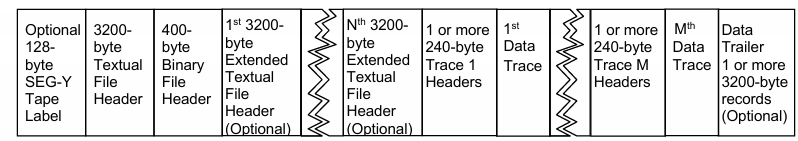


Based on the structure of the SGY file format, it becomes clear that important information may be stored in the different headers. The next step is to print these headers using both SGY import tools.

#### Text Header

According to our source, the structure should be as follows

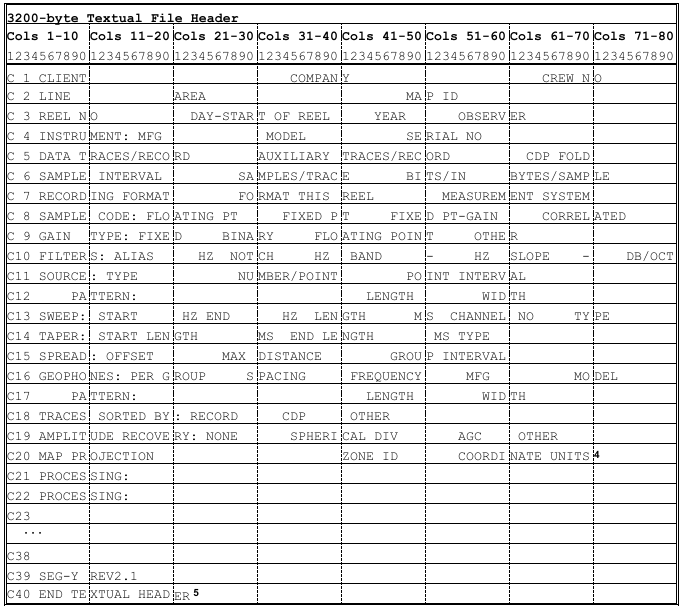

In [3]:
import codecs
## obspy Textual File Header for first file
textual_file_header = obspy_1.textual_file_header

#decode the header
decoded_header = codecs.decode(textual_file_header, "cp500")

for line in range(0, len(decoded_header), 80):
    print(decoded_header[line:line+80])

C 1                                                                             
C 2                                                                             
C 3                                                                             
C 4                                                                             
C 5                                                                             
C 6                                                                             
C 7                                                                             
C 8                                                                             
C 9                                                                             
C10                                                                             
C11                                                                             
C12                                                                             
C13                         

In [4]:
import codecs
## obspy Textual File Header for second file
textual_file_header = obspy_2.textual_file_header

#decode the header
decoded_header = codecs.decode(textual_file_header, "cp500")

for line in range(0, len(decoded_header), 80):
    print(decoded_header[line:line+80])

C 1                                                                             
C 2                                                                             
C 3                                                                             
C 4                                                                             
C 5                                                                             
C 6                                                                             
C 7                                                                             
C 8                                                                             
C 9                                                                             
C10                                                                             
C11                                                                             
C12                                                                             
C13                         

In [5]:
## segyio Textual File Header for first file
textual_file_header_segyio = segyio.tools.wrap(segyio_1.text[0])
print(textual_file_header_segyio)




C 1
C 2
C 3
C 4
C 5
C 6
C 7
C 8
C 9
C10
C11
C12
C13
C14
C15
C16
C17
C18
C19
C20
C21
C22
C23
C24
C25
C26
C27
C28
C29
C30
C31
C32
C33
C34
C35
C36
C37
C38
C39
C40 ED EBCDIC


In [6]:
## segyio Textual File Header for second file
textual_file_header_segyio = segyio.tools.wrap(segyio_2.text[0])
print(textual_file_header_segyio)

C 1
C 2
C 3
C 4
C 5
C 6
C 7
C 8
C 9
C10
C11
C12
C13
C14
C15
C16
C17
C18
C19
C20
C21
C22
C23
C24
C25
C26
C27
C28
C29
C30
C31
C32
C33
C34
C35
C36
C37
C38
C39
C40 ED EBCDIC


As we have now managed to print the text file header with both tools and for both files, it becomes clear that these headers contain no information.

#### Binary Header

As shown in the picture below, there may be important information in the binary header, as it contains binary values that are relevant for the entire SGY file.

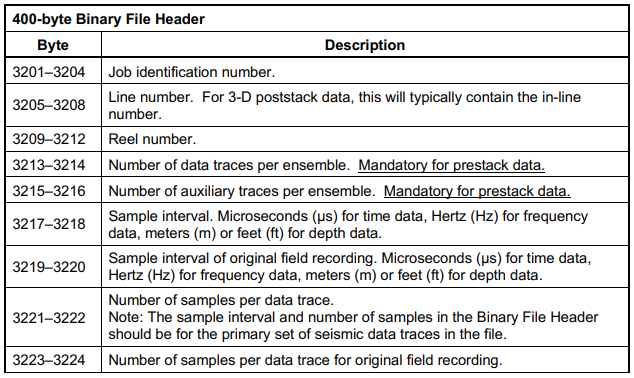 \
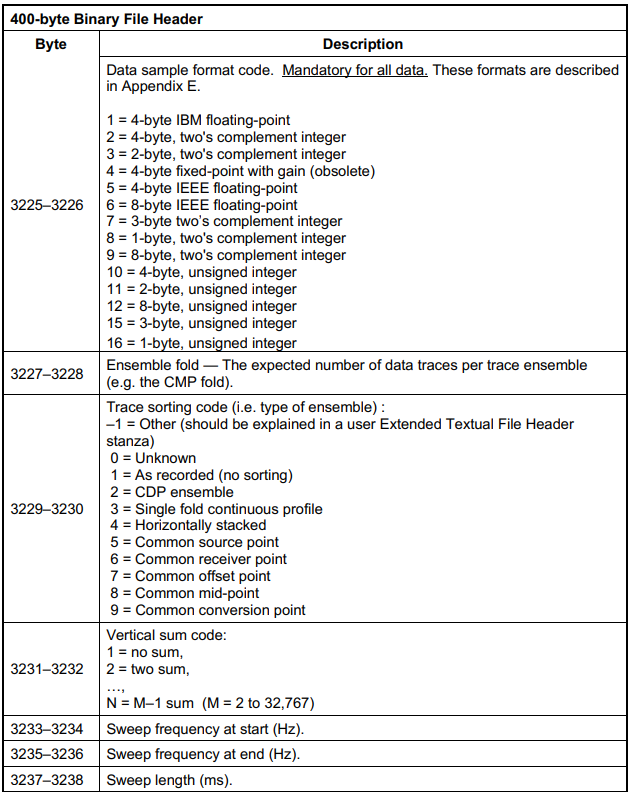 \
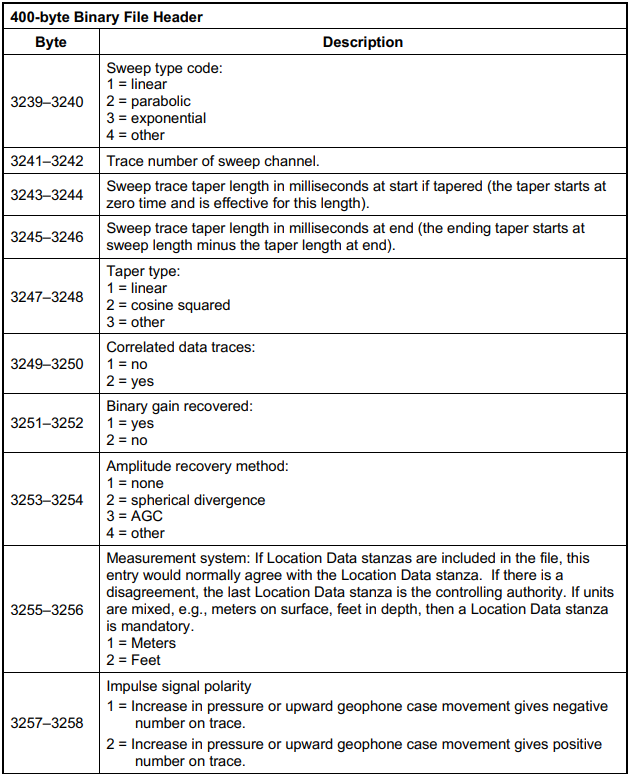 \
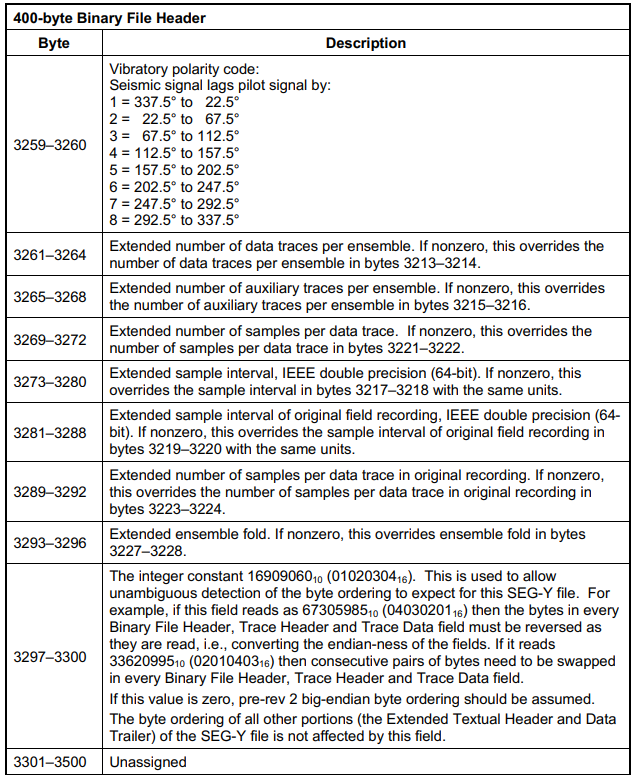 \
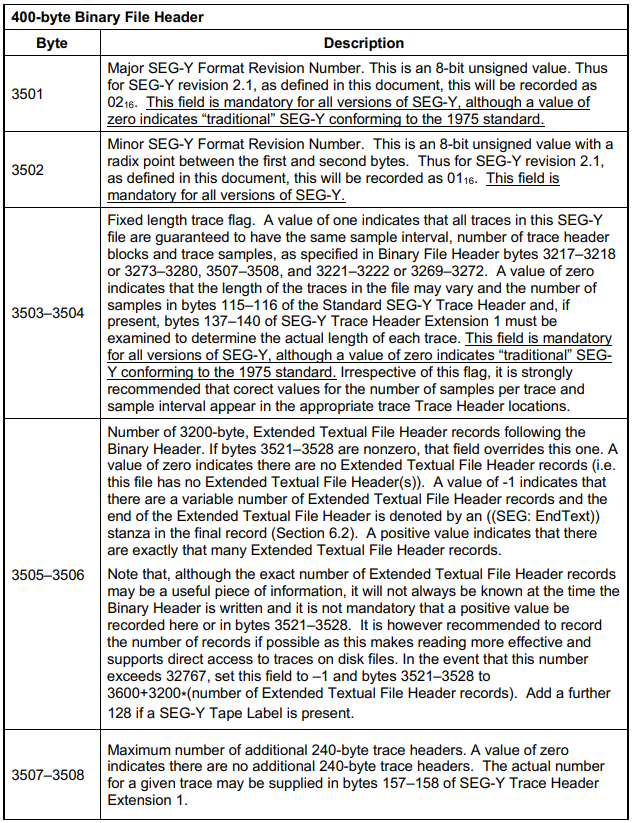 \
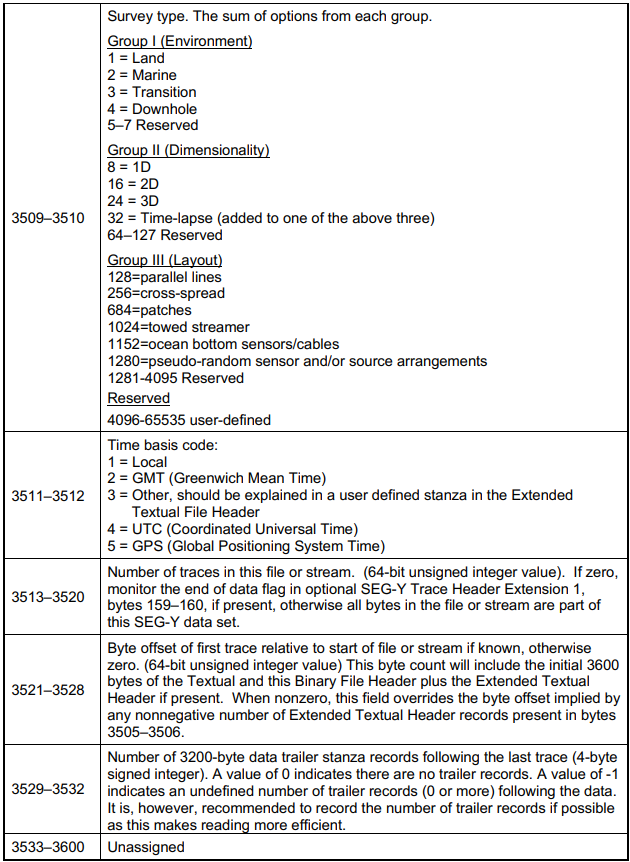 \



In [7]:
#Binary Header for obspy for file 1
binary_header_obspy_1 = obspy_1.binary_file_header
print(binary_header_obspy_1)

Binary File Header:
	job_identification_number: 0
	line_number: 0
	reel_number: 0
	number_of_data_traces_per_ensemble: 1
	number_of_auxiliary_traces_per_ensemble: 0
	sample_interval_in_microseconds: 49
	sample_interval_in_microseconds_of_original_field_recording: 0
	number_of_samples_per_data_trace: 400
	number_of_samples_per_data_trace_for_original_field_recording: 0
	data_sample_format_code: 3
	ensemble_fold: 1
	trace_sorting_code: 0
	vertical_sum_code: 0
	sweep_frequency_at_start: 0
	sweep_frequency_at_end: 0
	sweep_length: 0
	sweep_type_code: 0
	trace_number_of_sweep_channel: 0
	sweep_trace_taper_length_in_ms_at_start: 0
	sweep_trace_taper_length_in_ms_at_end: 0
	taper_type: 0
	correlated_data_traces: 0
	binary_gain_recovered: 0
	amplitude_recovery_method: 0
	measurement_system: 1
	impulse_signal_polarity: 0
	vibratory_polarity_code: 0
	unassigned_1: b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [8]:
#Binary Header for obspy for file 2
binary_header_obspy_2 = obspy_2.binary_file_header
print(binary_header_obspy_2)

Binary File Header:
	job_identification_number: 0
	line_number: 0
	reel_number: 0
	number_of_data_traces_per_ensemble: 1
	number_of_auxiliary_traces_per_ensemble: 0
	sample_interval_in_microseconds: 49
	sample_interval_in_microseconds_of_original_field_recording: 0
	number_of_samples_per_data_trace: 400
	number_of_samples_per_data_trace_for_original_field_recording: 0
	data_sample_format_code: 3
	ensemble_fold: 1
	trace_sorting_code: 0
	vertical_sum_code: 0
	sweep_frequency_at_start: 0
	sweep_frequency_at_end: 0
	sweep_length: 0
	sweep_type_code: 0
	trace_number_of_sweep_channel: 0
	sweep_trace_taper_length_in_ms_at_start: 0
	sweep_trace_taper_length_in_ms_at_end: 0
	taper_type: 0
	correlated_data_traces: 0
	binary_gain_recovered: 0
	amplitude_recovery_method: 0
	measurement_system: 1
	impulse_signal_polarity: 0
	vibratory_polarity_code: 0
	unassigned_1: b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [9]:
#Binary Header for segyio for file 1
from pprint import pprint
bin_header_segyio_1 = dict(segyio_1.bin)
pprint(bin_header_segyio_1)


{JobID: 0,
 LineNumber: 0,
 ReelNumber: 0,
 Traces: 1,
 AuxTraces: 0,
 Format: 3,
 Interval: 49,
 IntervalOriginal: 0,
 Samples: 400,
 SamplesOriginal: 0,
 EnsembleFold: 1,
 SortingCode: 0,
 VerticalSum: 0,
 SweepFrequencyStart: 0,
 SweepFrequencyEnd: 0,
 SweepLength: 0,
 Sweep: 0,
 SweepChannel: 0,
 SweepTaperStart: 0,
 SweepTaperEnd: 0,
 Taper: 0,
 CorrelatedTraces: 0,
 BinaryGainRecovery: 0,
 AmplitudeRecovery: 0,
 MeasurementSystem: 1,
 ImpulseSignalPolarity: 0,
 VibratoryPolarity: 0,
 ExtAuxTraces: 0,
 ExtSamples: 0,
 ExtSamplesOriginal: 0,
 ExtEnsembleFold: 0,
 SEGYRevision: 0,
 SEGYRevisionMinor: 0,
 TraceFlag: 0,
 ExtendedHeaders: 0}


In [10]:
#Binary Header for segyio for file 1
from pprint import pprint
bin_header_segyio_2 = dict(segyio_2.bin)
pprint(bin_header_segyio_2)

{JobID: 0,
 LineNumber: 0,
 ReelNumber: 0,
 Traces: 1,
 AuxTraces: 0,
 Format: 3,
 Interval: 49,
 IntervalOriginal: 0,
 Samples: 400,
 SamplesOriginal: 0,
 EnsembleFold: 1,
 SortingCode: 0,
 VerticalSum: 0,
 SweepFrequencyStart: 0,
 SweepFrequencyEnd: 0,
 SweepLength: 0,
 Sweep: 0,
 SweepChannel: 0,
 SweepTaperStart: 0,
 SweepTaperEnd: 0,
 Taper: 0,
 CorrelatedTraces: 0,
 BinaryGainRecovery: 0,
 AmplitudeRecovery: 0,
 MeasurementSystem: 1,
 ImpulseSignalPolarity: 0,
 VibratoryPolarity: 0,
 ExtAuxTraces: 0,
 ExtSamples: 0,
 ExtSamplesOriginal: 0,
 ExtEnsembleFold: 0,
 SEGYRevision: 0,
 SEGYRevisionMinor: 0,
 TraceFlag: 0,
 ExtendedHeaders: 0}


A difference between the two packages, segyio and ObsPy, can be spotted in terms of intepretability immediately. The segyio package uses much shorter and more readable key names compared to ObsPy, as shown in the picture above. However, in both cases the keys do not appear to be sorted by byte position but this is not a major issue.

Furthermore, the analysis shows that the file is not **SGY Rev. 1**, as indicated by the field **SEGYRevision: 0**. This suggests that it may be **SGY Rev. 0**.
Further analysis is based on the following sources:

- https://library.seg.org/pb-assets/technical-standards/seg_y_rev1-1686080991247.pdf

- https://library.seg.org/pb-assets/technical-standards/seg_y_rev0-1686080980707.pdf

- https://segy.readthedocs.io/en/latest/data_models/file.html

**Based on the interpretation of the headers using the segyio package, the further analysis of the data will be carried out with segyio, as it provides an easier and more readable structure.**

The Binary Header is structured as follows according to **SGY REV 0**

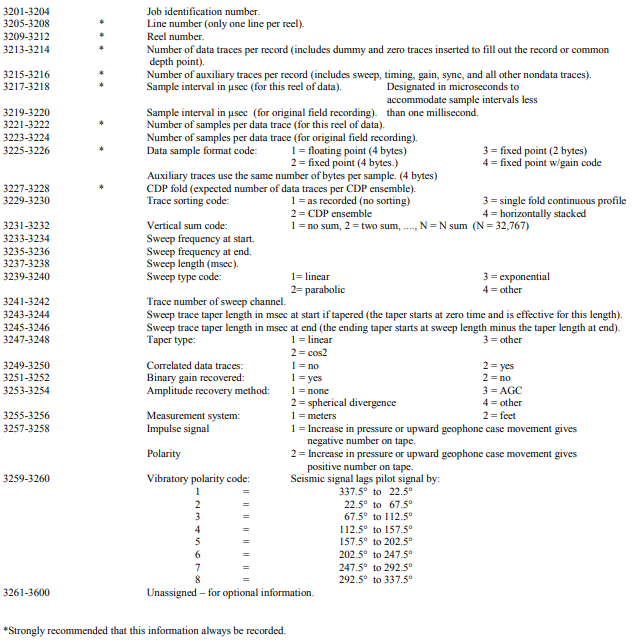

Since most fields in the textual header are zero, the further analysis of the data is based on the binary header, focusing specifically on the fields that are non-zero.

In [11]:
# get the header fields with information file1
# create a Real dict out of 
bin_header_dict_segyio_1 = dict(bin_header_segyio_1)
for key, value in bin_header_dict_segyio_1.items():
    if value > 0 :
        print(f"{key}: {value}")


Traces: 1
Interval: 49
Samples: 400
Format: 3
EnsembleFold: 1
MeasurementSystem: 1


In [12]:
# get the header fields with information file2
# create a Real dict out of 
bin_header_dict_segyio_2 = dict(bin_header_segyio_2)
for key, value in bin_header_dict_segyio_1.items():
    if value > 0 :
        print(f"{key}: {value}")

Traces: 1
Interval: 49
Samples: 400
Format: 3
EnsembleFold: 1
MeasurementSystem: 1


Since file 1 and File 2 are excactly the same 
following meanings are found:

 |Field|Value|Meaning|
 |-----|-----|-------|
 |Traces|1|Number of Data Traces per Record|
 |Interval|49|Sample Interval in (microseconds)|
 |Samples|400|Number of Samples in one Trace|
 |Format|3|Data Sample Format code: 3 is fixed point|
 |EnsembleFold|1|Number of expected data traces per CDP ensemble|
 |measurement System|1|meter|

#### Trace Header

According to the Source the fields should be like this.

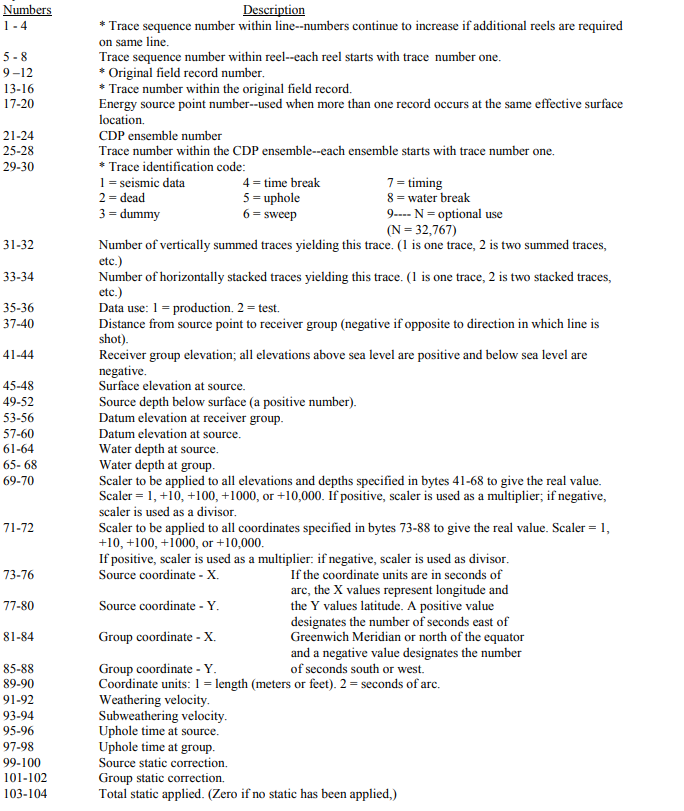
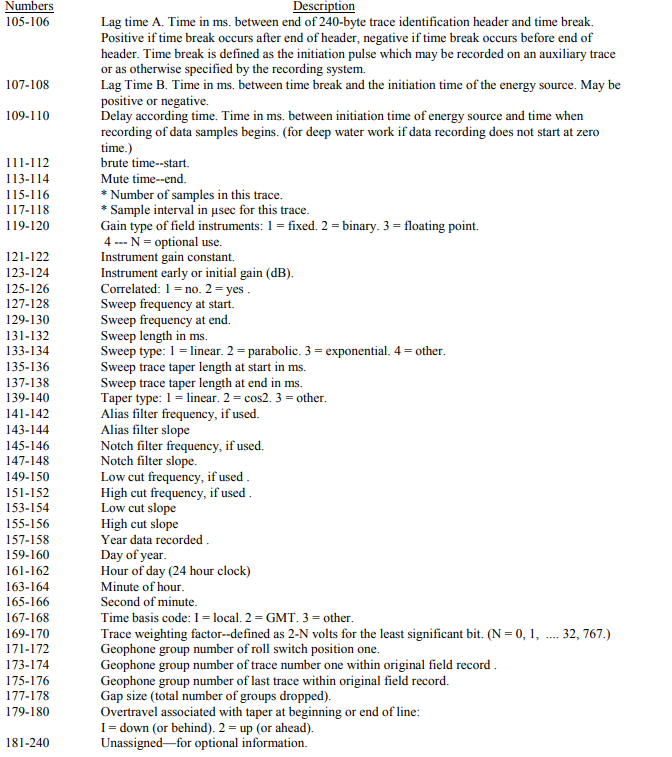

In [17]:
#trace Header from trace 1 and file 1
from pprint import pprint
trace_header_0_file_1 = dict(segyio_1.header[0])
pprint(trace_header_0_file_1)

{TRACE_SEQUENCE_FILE: 1,
 FieldRecord: 1,
 TRACE_SEQUENCE_LINE: 1,
 TraceNumber: 1,
 EnergySourcePoint: 1,
 NStackedTraces: 0,
 CDP: 1,
 CDP_TRACE: 0,
 TraceIdentificationCode: 1,
 NSummedTraces: 0,
 DataUse: 0,
 offset: 0,
 ReceiverGroupElevation: 0,
 SourceSurfaceElevation: 0,
 SourceDepth: 0,
 ReceiverDatumElevation: 0,
 SourceDatumElevation: 0,
 SourceWaterDepth: 0,
 GroupWaterDepth: 0,
 ElevationScalar: 1,
 SourceGroupScalar: 1,
 SourceX: 0,
 SourceY: 0,
 GroupX: 0,
 GroupY: 0,
 CoordinateUnits: 0,
 WeatheringVelocity: 0,
 SubWeatheringVelocity: 0,
 SourceUpholeTime: 0,
 GroupUpholeTime: 0,
 SourceStaticCorrection: 0,
 GroupStaticCorrection: 0,
 TotalStaticApplied: 0,
 LagTimeA: 0,
 LagTimeB: 0,
 DelayRecordingTime: 0,
 MuteTimeStart: 0,
 MuteTimeEND: 0,
 TRACE_SAMPLE_COUNT: 400,
 TRACE_SAMPLE_INTERVAL: 49,
 GainType: 0,
 InstrumentGainConstant: 0,
 InstrumentInitialGain: 0,
 Correlated: 0,
 SweepFrequencyStart: 0,
 SweepFrequencyEnd: 0,
 SweepLength: 0,
 SweepType: 0,
 SweepTrace

In [18]:
#trace Header from trace 1 and file 2
from pprint import pprint

trace_header_0_file_2 = dict(segyio_2.header[0])
pprint(trace_header_0_file_2)

{TRACE_SEQUENCE_FILE: 1,
 FieldRecord: 1,
 TRACE_SEQUENCE_LINE: 1,
 TraceNumber: 1,
 EnergySourcePoint: 1,
 NStackedTraces: 0,
 CDP: 1,
 CDP_TRACE: 0,
 TraceIdentificationCode: 1,
 NSummedTraces: 0,
 DataUse: 0,
 offset: 0,
 ReceiverGroupElevation: 0,
 SourceSurfaceElevation: 0,
 SourceDepth: 0,
 ReceiverDatumElevation: 0,
 SourceDatumElevation: 0,
 SourceWaterDepth: 0,
 GroupWaterDepth: 0,
 ElevationScalar: 1,
 SourceGroupScalar: 1,
 SourceX: 0,
 SourceY: 0,
 GroupX: 0,
 GroupY: 0,
 CoordinateUnits: 0,
 WeatheringVelocity: 0,
 SubWeatheringVelocity: 0,
 SourceUpholeTime: 0,
 GroupUpholeTime: 0,
 SourceStaticCorrection: 0,
 GroupStaticCorrection: 0,
 TotalStaticApplied: 0,
 LagTimeA: 0,
 LagTimeB: 0,
 DelayRecordingTime: 0,
 MuteTimeStart: 0,
 MuteTimeEND: 0,
 TRACE_SAMPLE_COUNT: 400,
 TRACE_SAMPLE_INTERVAL: 49,
 GainType: 0,
 InstrumentGainConstant: 0,
 InstrumentInitialGain: 0,
 Correlated: 0,
 SweepFrequencyStart: 0,
 SweepFrequencyEnd: 0,
 SweepLength: 0,
 SweepType: 0,
 SweepTrace

Analysis of the trace header for both files shows that most fields are zero. Once again, the analysis focuses on the fields that are non-zero.

In [19]:
# get the header fields with information file1
# create a Real dict out of 

trace_0_header_dict_segyio_1 = dict(trace_header_0_file_1)
for key, value in trace_0_header_dict_segyio_1.items():
    if value > 0 :
        print(f"{key}: {value}")

TRACE_SEQUENCE_LINE: 1
TRACE_SEQUENCE_FILE: 1
FieldRecord: 1
TraceNumber: 1
EnergySourcePoint: 1
CDP: 1
TraceIdentificationCode: 1
ElevationScalar: 1
SourceGroupScalar: 1
TRACE_SAMPLE_COUNT: 400
TRACE_SAMPLE_INTERVAL: 49
INLINE_3D: 1
CROSSLINE_3D: 1


In [20]:
# get the header fields with information file1
# create a Real dict out of 
trace_0_header_dict_segyio_2 = dict(trace_header_0_file_2)
for key, value in trace_0_header_dict_segyio_2.items():
    if value > 0 :
        print(f"{key}: {value}")

TRACE_SEQUENCE_LINE: 1
TRACE_SEQUENCE_FILE: 1
FieldRecord: 1
TraceNumber: 1
EnergySourcePoint: 1
CDP: 1
TraceIdentificationCode: 1
ElevationScalar: 1
SourceGroupScalar: 1
TRACE_SAMPLE_COUNT: 400
TRACE_SAMPLE_INTERVAL: 49
CROSSLINE_3D: 1


Analysis shows that there are fields which do not appear in the referenced sources—specifically the fields **CROSSLINE_3D, INLINE_3D, CDP_X, CDP_Y**. According to the following source, there is a variety of ways in which data may be stored in the headers:
https://segy.readthedocs.io/en/latest/data_models/file.html
Furthermore, according to:
https://www.moveoutdata.net/wp-content/uploads/2022/06/SEG-Y-Format-rev-1.pdf


these fields have fixed positions in SEG-Y Rev 1.0, as shown in the table below.

The next step is to check whether the additional fields in our files are located at the corresponding byte positions. This is necessary to determine whether the file is a Rev 0 file with custom header extensions or possibly a Rev 1 file that simply does not declare its revision in the binary header.

|Byte|Field Name|
|-|-|
|181-184|CDP_X|
|185-188|CDP_Y|
|189-192|INLINE_3D|
|193-196|CROSSLINE_3D|

In [21]:
#Checking Bytepositions for file 1

for name in dir(segyio.TraceField):
    byte_pos = getattr(segyio.TraceField, name)
    if name.isupper() and byte_pos >= 181:
        value = trace_header_0_file_1.get(byte_pos, None)
        print(f"{name:25s} -> Byte {byte_pos} | Value: {value}")

CDP_X                     -> Byte 181 | Value: 0
CDP_Y                     -> Byte 185 | Value: 0
CROSSLINE_3D              -> Byte 193 | Value: 1
INLINE_3D                 -> Byte 189 | Value: 1


In [22]:
#Checking Bytepositions for file 2

for name in dir(segyio.TraceField):
    byte_pos = getattr(segyio.TraceField, name)
    if name.isupper() and byte_pos >= 181:
        value = trace_header_0_file_2.get(byte_pos, None)
        print(f"{name:25s} -> Byte {byte_pos} | Value: {value}")

CDP_X                     -> Byte 181 | Value: 0
CDP_Y                     -> Byte 185 | Value: 0
CROSSLINE_3D              -> Byte 193 | Value: 1
INLINE_3D                 -> Byte 189 | Value: 0


Once again the meaning of these headers is shown below.

| Field                    | Value | Meaning |
|---------------------------|--------|------------------|
| TRACE_SEQUENCE_LINE       | 1      | Position of the trace within the current line. |
| TRACE_SEQUENCE_FILE       | 1      | Position of the trace within the file. |
| FieldRecord               | 1      | Field record number where the trace was recorded. |
| TraceNumber               | 1      | Unique number identifying this trace within the record. |
| EnergySourcePoint         | 1      | Shot point or source location number. |
| CDP                       | 1      | Common Depth Point (gather identifier). |
| TraceIdentificationCode   | 1      | Type of trace (e.g., seismic data, dead trace, test, etc.). |
| ElevationScalar           | 1      | Scale factor applied to elevation values. |
| SourceGroupScalar         | 1      | Scale factor for source and receiver group coordinates. |
| TRACE_SAMPLE_COUNT        | 400    | Number of samples per trace. |
| TRACE_SAMPLE_INTERVAL     | 49     | Time interval between samples (microseconds). |
| CDP_X                     | 0      | X-coordinate of the CDP position. |
| CDP_Y                     | 0      | Y-coordinate of the CDP position. |
| INLINE_3D                 | 1      | Inline number (3D line index). |
| CROSSLINE_3D              | 1      | Crossline number (3D cross-index). |


And surely the most important information in the trace headers are the fields TraceNumber, INLINE_3D, CROSSLINE_3D, TRACE_SAMPLE_COUNT, TRACE_SAMPLE_INTERVAL.
The fields TraceNumber, INLINE_3D, CROSSLINE_3D define the 3D structure of the dataset, which means that radargrams can be reconstructed.

To plot a radargram from an inline perspective, all crosslines must be sorted in ascending order.
Conversely, for a crossline plot, all inlines must be sorted in ascending order.

For a timeslice plot (bird’s-eye view), a matrix of Inlines × Crosslines must be created for every time slice.

To easily access the different amplitudes in the traces, a DataFrame is created with the following structure

|Trace|Inline|Crossline|Amplitudes|
|-----|---|-|-|

In [23]:
#creating Dataframe for file 1
#optional crwation of a csv
import numpy as np
import pandas as pd
rows= []

inlines   = segyio_1.attributes(segyio.TraceField.INLINE_3D)[:]
crosslines = segyio_1.attributes(segyio.TraceField.CROSSLINE_3D)[:]

for i in range(segyio_1.tracecount):
    amp = np.array(segyio_1.trace[i])
    inl = inlines[i]
    cross = crosslines[i]
    rows.append({
        "trace": i,
        "inline": inl,
        "crossline": cross,
        "Amplitude": amp
    })
df1 = pd.DataFrame(rows)
#df.to_csv("inline_crossline_segyio.csv", index =False)
print(df1.head())


   trace  inline  crossline                                          Amplitude
0      0       1          1  [-20228, -14833, -12170, -9433, -11480, -12543...
1      1       1          2  [-19524, -15504, -13631, -10211, -10939, -1103...
2      2       1          3  [-18915, -16373, -15126, -10702, -10026, -9497...
3      3       1          4  [-18675, -16565, -15221, -10267, -9359, -9442,...
4      4       1          5  [-17714, -17046, -16254, -10498, -8612, -8687,...


In [24]:
#creating Dataframe for file 2
#optional crwation of a csv
import numpy as np
import pandas as pd
rows= []

inlines   = segyio_2.attributes(segyio.TraceField.INLINE_3D)[:]
crosslines = segyio_2.attributes(segyio.TraceField.CROSSLINE_3D)[:]

for i in range(segyio_2.tracecount):
    amp = np.array(segyio_2.trace[i])
    inl = inlines[i]
    cross = crosslines[i]
    rows.append({
        "trace": i,
        "inline": inl,
        "crossline": cross,
        "Amplitude": amp
    })
df2 = pd.DataFrame(rows)
#df.to_csv("inline_crossline_segyio.csv", index =False)
print(df2.head())

   trace  inline  crossline                                          Amplitude
0      0       0          1  [-3779, -4808, -5511, -5421, -7800, -8821, -89...
1      1       0          2  [-3556, -4759, -5628, -5542, -7783, -8609, -86...
2      2       0          3  [-3445, -4734, -5746, -5699, -7867, -8492, -83...
3      3       0          4  [-3323, -4768, -5893, -5817, -7865, -8306, -80...
4      4       0          5  [-3376, -4907, -6050, -5876, -7803, -8150, -78...


The analysis shows that the data is structured as a grid.
**Note: Although it may look like there are only single lines, each inline actually contains many crosslines.**

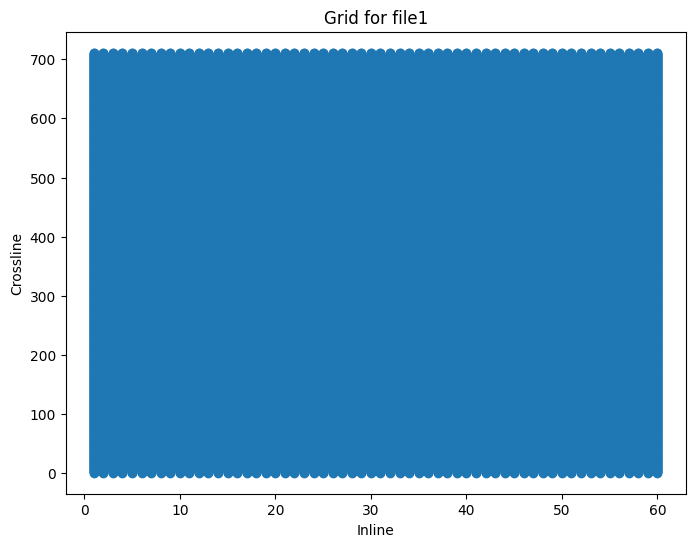

In [25]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))
plt.scatter(df1["inline"], df1["crossline"])
plt.xlabel("Inline")
plt.ylabel("Crossline")
plt.title(f"Grid for file1")
plt.show()

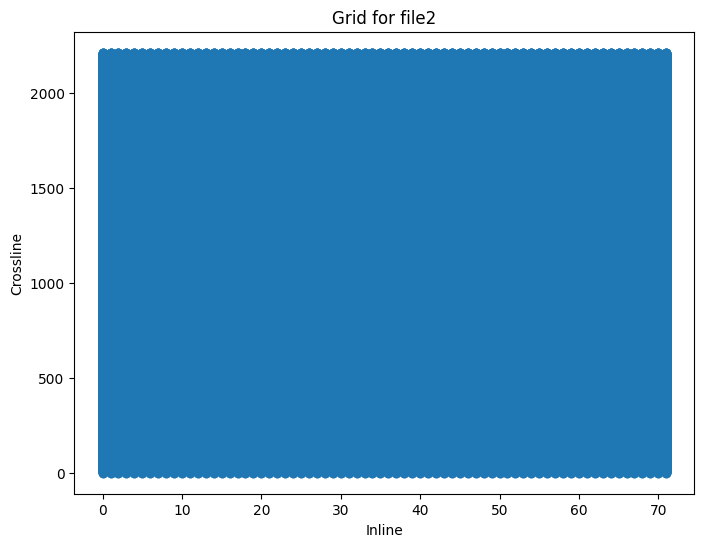

In [26]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))
plt.scatter(df2["inline"], df2["crossline"])
plt.xlabel("Inline")
plt.ylabel("Crossline")
plt.title(f"Grid for file2")
plt.show()

This shows that there is a higher density along the crosslines, which means that plotting the traces per inline should result in more detailed radargrams.

### Chapter 3: Validating that the data is 3D

what does a real 3D Dataset mean?
- According to our findings and the source
    https://www.sandmeier-geo.de/Download/3d_datainterpretation.pdf,
    a real 3D dataset is characterized by a grid in which each grid point corresponds to exactly one trace.
    This means that every trace can be uniquely located in the grid, for example at coordinates
    (x, y) = (inline number, crossline number).

- In our DataFrame the crosslines for each inline are repeating, indicating that the data does follow the expected structure of a fully regular 3D grid.

for example:

**3D Data**

| trace | inline | crossline | amplitude |
|--------|--------|-----------|-----------|
| 1      | 1      | 1         | ...       |
| 2      | 1      | 2         | ...       |
| 3      | 2      | 1         | ...       |
| 4      | 2      | 2         | ...       |


**2D Data**

| trace | inline | amplitude |
|--------|----------|-----------|
| 1      | 1        | ...       |
| 2      | 1    | ...       |
| 3      | 2    | ...       |
| 4      | 2    | ...       |


The Code below shows a validation method


In [27]:
# Testing if Data is 3D or 2D
# testing for file 1

#extracting unique inlines and crosslines
import pandas as pd


# unique inline and Croslline combinations
combo_counts = df1.groupby(["inline", "crossline"]).size().reset_index(name="count")

# duplicated combinations
duplicates = combo_counts[combo_counts["count"] > 1]

# counting unique combinations
unique_pairs = len(combo_counts)

#counting number od traces
total_traces = len(df1)

# number of inlines and crosslines
n_inl = df1["inline"].nunique()
n_xl = df1["crossline"].nunique()

# Analyse
if len(duplicates) > 0:
    data_type = "2D"
elif n_inl == 1 or n_xl == 1:
    data_type = "2D"
elif unique_pairs == total_traces:
    data_type = "3D (unique combinations)"
else:
    data_type = "could not determine datatype"

print(f"Inlines: {n_inl}, Crosslines: {n_xl}")
print(f"Traces: {total_traces}, Unique Pairs: {unique_pairs}")
print(f"Number of duplicated combinations: {len(duplicates)}")
print(f"Datatype: {data_type}")





Inlines: 60, Crosslines: 711
Traces: 42660, Unique Pairs: 42660
Number of duplicated combinations: 0
Datatype: 3D (unique combinations)


In [28]:
# Testing if Data is 3D or 2D
# testing for file 2

#extracting unique inlines and crosslines
import pandas as pd


# unique inline and Croslline combinations
combo_counts = df2.groupby(["inline", "crossline"]).size().reset_index(name="count")

# duplicated combinations
duplicates = combo_counts[combo_counts["count"] > 1]

# counting unique combinations
unique_pairs = len(combo_counts)

#counting number od traces
total_traces = len(df2)

# number of inlines and crosslines
n_inl = df2["inline"].nunique()
n_xl = df2["crossline"].nunique()

# Analyse
if len(duplicates) > 0:
    data_type = "2D"
elif n_inl == 1 or n_xl == 1:
    data_type = "2D"
elif unique_pairs == total_traces:
    data_type = "3D (unique combinations)"
else:
    data_type = "could not determine datatype"

print(f"Inlines: {n_inl}, Crosslines: {n_xl}")
print(f"Traces: {total_traces}, Unique Pairs: {unique_pairs}")
print(f"Number of duplicated combinations: {len(duplicates)}")
print(f"Datatype: {data_type}")





Inlines: 72, Crosslines: 2211
Traces: 159192, Unique Pairs: 159192
Number of duplicated combinations: 0
Datatype: 3D (unique combinations)


Visually a pivot Table can be created to see the unique combinations.

In [32]:
#pivot table for file 1
inlines = df1["inline"].nunique()
crosslines = df1["crossline"].nunique()

#create the pivot table
pivot = df1.pivot_table(index="inline", columns="crossline", aggfunc="size", fill_value=0)
print(pivot)

if pivot.shape[0] == inlines and pivot.shape[1] == crosslines:
    print("-------------------------------")
    print("Datatype: 3D")

crossline  1    2    3    4    5    6    7    8    9    10   ...  702  703  \
inline                                                       ...             
1            1    1    1    1    1    1    1    1    1    1  ...    1    1   
2            1    1    1    1    1    1    1    1    1    1  ...    1    1   
3            1    1    1    1    1    1    1    1    1    1  ...    1    1   
4            1    1    1    1    1    1    1    1    1    1  ...    1    1   
5            1    1    1    1    1    1    1    1    1    1  ...    1    1   
6            1    1    1    1    1    1    1    1    1    1  ...    1    1   
7            1    1    1    1    1    1    1    1    1    1  ...    1    1   
8            1    1    1    1    1    1    1    1    1    1  ...    1    1   
9            1    1    1    1    1    1    1    1    1    1  ...    1    1   
10           1    1    1    1    1    1    1    1    1    1  ...    1    1   
11           1    1    1    1    1    1    1    1    1    1  ...

In [31]:
#pivot table for file 2
inlines = df2["inline"].nunique()
crosslines = df2["crossline"].nunique()

#create the pivot table
pivot = df2.pivot_table(index="inline", columns="crossline", aggfunc="size", fill_value=0)
print(pivot)

if pivot.shape[0] == inlines and pivot.shape[1] == crosslines:
    print("-------------------------------")
    print("Datatype: 3D")
    


crossline  1     2     3     4     5     6     7     8     9     10    ...  \
inline                                                                 ...   
0             1     1     1     1     1     1     1     1     1     1  ...   
1             1     1     1     1     1     1     1     1     1     1  ...   
2             1     1     1     1     1     1     1     1     1     1  ...   
3             1     1     1     1     1     1     1     1     1     1  ...   
4             1     1     1     1     1     1     1     1     1     1  ...   
...         ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
67            1     1     1     1     1     1     1     1     1     1  ...   
68            1     1     1     1     1     1     1     1     1     1  ...   
69            1     1     1     1     1     1     1     1     1     1  ...   
70            1     1     1     1     1     1     1     1     1     1  ...   
71            1     1     1     1     1     1     1     1     1 

## Chapter 4: Plotting radargrams

With the knowledge from the beforehand Chapters Radargrams can be recreated.

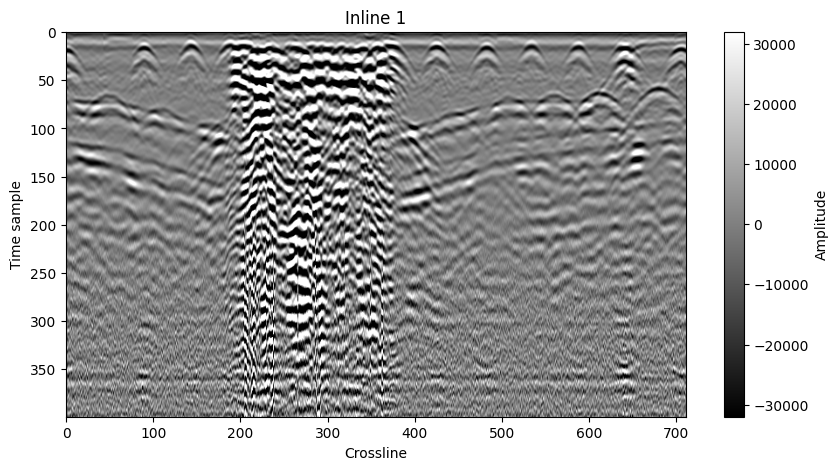

In [33]:
#Plot for file 1
#we take the first inline
import numpy as np
import matplotlib.pyplot as plt

def plot_inline(df, inlinenr):
    
    
    sub = df[df["inline"] == inlinenr].sort_values("crossline")
    traces = np.vstack(sub["Amplitude"].values)
    img = traces.T

    plt.figure(figsize=(10, 5))
    plt.imshow(img, cmap="grey", aspect="auto", origin="upper")
    plt.title(f"Inline {inlinenr}")
    plt.xlabel("Crossline")
    plt.ylabel("Time sample")
    plt.colorbar(label="Amplitude")
    plt.show()


plot_inline(df1, 1)

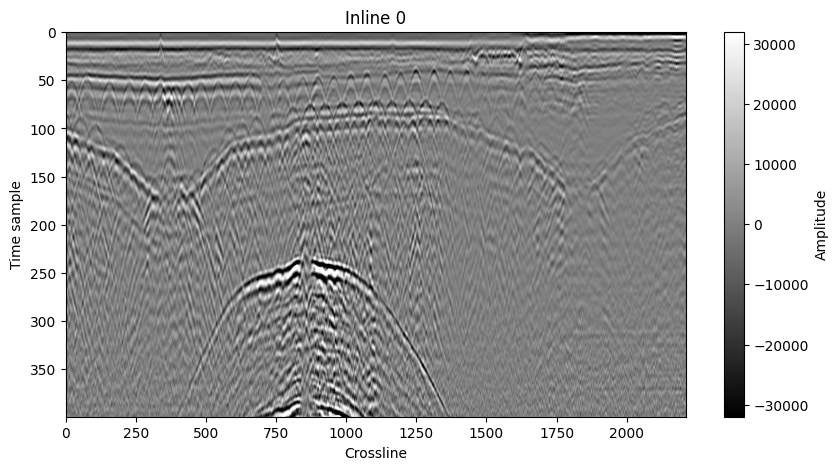

In [34]:
#Plot for file 2
#we take the first inline
import numpy as np
import matplotlib.pyplot as plt

def plot_inline(df, inlinenr):
    
    
    sub = df[df["inline"] == inlinenr].sort_values("crossline")
    traces = np.vstack(sub["Amplitude"].values)
    img = traces.T

    plt.figure(figsize=(10, 5))
    plt.imshow(img, cmap="grey", aspect="auto", origin="upper")
    plt.title(f"Inline {inlinenr}")
    plt.xlabel("Crossline")
    plt.ylabel("Time sample")
    plt.colorbar(label="Amplitude")
    plt.show()


plot_inline(df2, 0)

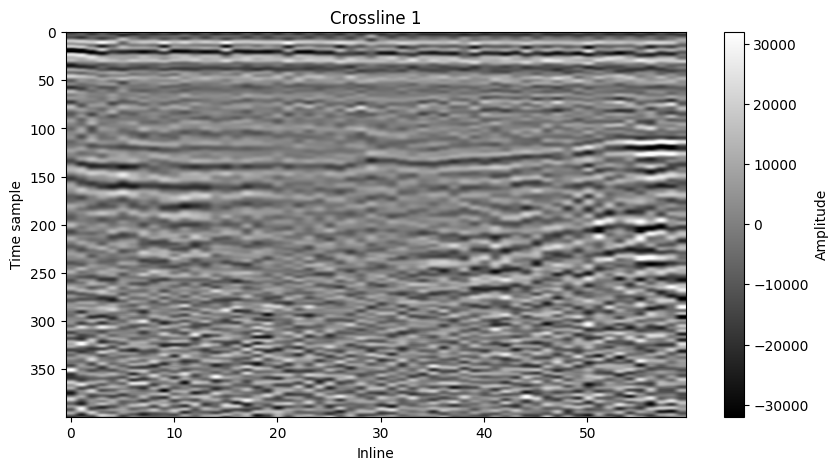

In [35]:
#plot for file 1
# we take the first crossline
def plot_crossline(df, cross_nr):
    sub = df[df["crossline"] == cross_nr].sort_values("inline")
    traces = np.vstack(sub["Amplitude"].values)
    img = traces.T

    plt.figure(figsize=(10, 5))
    plt.imshow(img, cmap="gray", aspect="auto", origin="upper")
    plt.title(f"Crossline {cross_nr}")
    plt.xlabel("Inline")
    plt.ylabel("Time sample")
    plt.colorbar(label="Amplitude")
    plt.show()

plot_crossline(df1, 1)

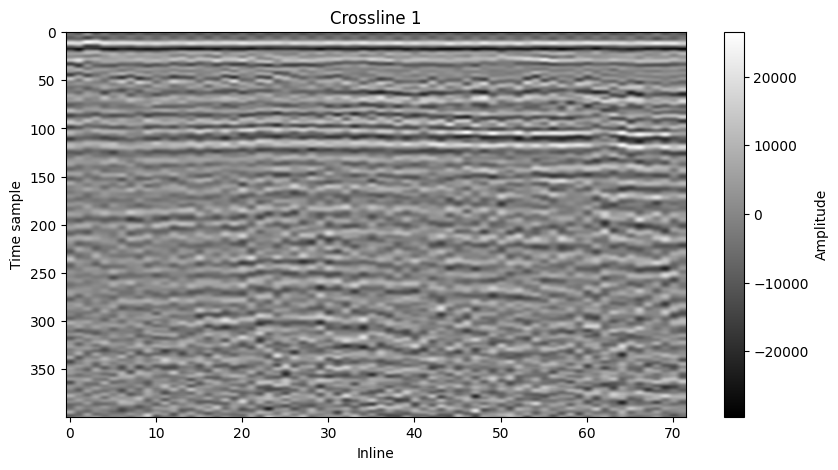

In [36]:
#plot for file 2
# we take the first crossline
def plot_crossline(df, cross_nr):
    sub = df[df["crossline"] == cross_nr].sort_values("inline")
    traces = np.vstack(sub["Amplitude"].values)
    img = traces.T

    plt.figure(figsize=(10, 5))
    plt.imshow(img, cmap="gray", aspect="auto", origin="upper")
    plt.title(f"Crossline {cross_nr}")
    plt.xlabel("Inline")
    plt.ylabel("Time sample")
    plt.colorbar(label="Amplitude")
    plt.show()

plot_crossline(df2, 1)

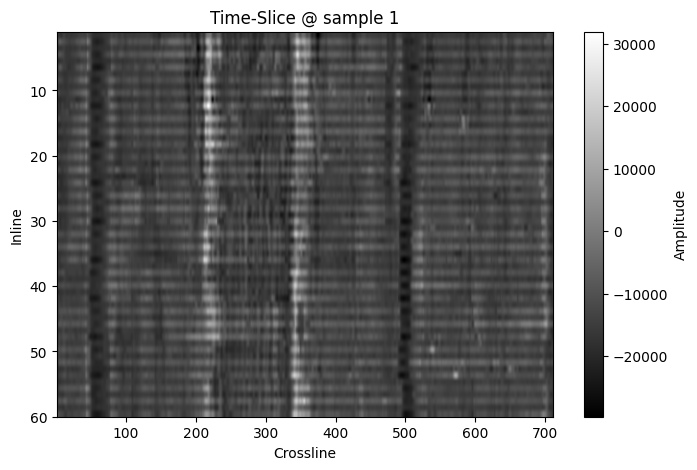

In [37]:
#plot for file 1
#plotting time slice (Biird view)
def plot_timeslice(df, sample_index):
    inlines = np.sort(df["inline"].unique())
    crosslines = np.sort(df["crossline"].unique())
    mat = np.full((len(inlines), len(crosslines)), np.nan)

    il_map = {v:i for i,v in enumerate(inlines)}
    cl_map = {v:i for i,v in enumerate(crosslines)}

    for _, row in df.iterrows():
        i = il_map[row["inline"]]
        j = cl_map[row["crossline"]]
        mat[i, j] = row["Amplitude"][sample_index]

    plt.figure(figsize=(8,5))
    plt.imshow(np.nan_to_num(mat), cmap="gray", aspect="auto",
               extent=[crosslines.min(), crosslines.max(), inlines.max(), inlines.min()])
    plt.title(f"Time-Slice @ sample {sample_index}")
    plt.xlabel("Crossline")
    plt.ylabel("Inline")
    plt.colorbar(label="Amplitude")
    plt.show()

plot_timeslice(df1, 1)

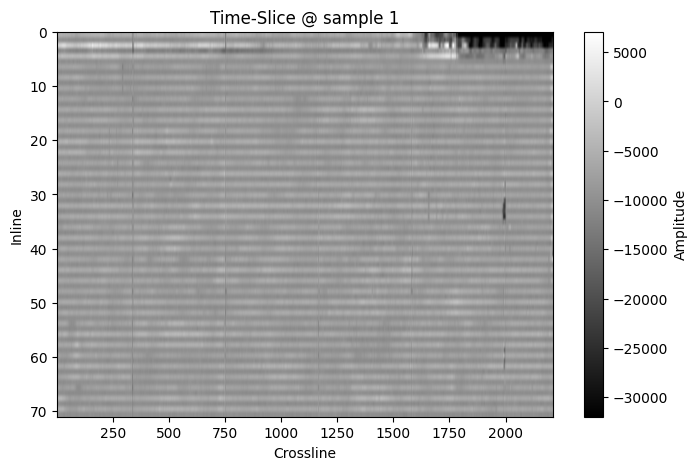

In [38]:
#plot for file 2
#plotting time slice (Biird view)
def plot_timeslice(df, sample_index):
    inlines = np.sort(df["inline"].unique())
    crosslines = np.sort(df["crossline"].unique())
    mat = np.full((len(inlines), len(crosslines)), np.nan)

    il_map = {v:i for i,v in enumerate(inlines)}
    cl_map = {v:i for i,v in enumerate(crosslines)}

    for _, row in df.iterrows():
        i = il_map[row["inline"]]
        j = cl_map[row["crossline"]]
        mat[i, j] = row["Amplitude"][sample_index]

    plt.figure(figsize=(8,5))
    plt.imshow(np.nan_to_num(mat), cmap="gray", aspect="auto",
               extent=[crosslines.min(), crosslines.max(), inlines.max(), inlines.min()])
    plt.title(f"Time-Slice @ sample {sample_index}")
    plt.xlabel("Crossline")
    plt.ylabel("Inline")
    plt.colorbar(label="Amplitude")
    plt.show()

plot_timeslice(df2, 1)

### Chapter 5: Implementations for Pipeline

Out of this knowledge of the above chapters the following class **DatatoolKit** is implemented into the **Pipeline Package**. \
the class includes the methods:
- Data Loading with segyio as **LoadSGY()** from Chapter 1
- creating the Dataframe as **create_df():** from Chapter 2
- plotting the Grid as **plot_grid()** from Chapter 2
- plotting the radargramms from Chapter 4
    - inline radargramm as **plot_inline_cut_raw()**
    - crossline radargramm as **plot_crossline_cut_raw()**
    - time slice radargramm as **plot_timeslice_cut_raw()**
- Analyzing Datatype as **analyse_datetype()**

the exact parameters the methods are needing and the final implementations are documented in the DataToolKit class.